In [3]:
from google.colab import drive
drive.mount('/content/drive')
# then update save paths e.g.
SAVE_ROOT = '/content/drive/MyDrive/dl_cw2'

Mounted at /content/drive


# Deep Learning
## Summative assessment
### Coursework 2

#### Instructions

This coursework is released on **5th March 9.00 (UK time)** and is due by **26th March 9.00 (UK time)**. It is worth **50%** of your overall mark. There are 4 questions in this assessment, and a total of 50 marks are available. **You should attempt to answer all questions.** In addition to the total number of marks shown per question below, an additional 5 marks is available for presentation and clarity/quality of code.

This assessment assesses your ability to implement and analyse implementations of Bayesian neural networks (BNNs). In particular, you will explore techniques for examining the performance and calibration properties of the trained models.

Throughout the development of your models in this assessment you should use the high level Keras `compile` and `fit` APIs to train your models (no custom training loops), making use of layer and model subclassing as appropriate.

You can make imports as and when you need them throughout the notebook, and add code cells where necessary. Make sure your notebook executes correctly in sequence before submitting.

#### Submission instructions

The submission for this assessment will consist of a notebook (.ipynb file) and PDF report.

Ensure your notebook executes correctly in order. Save your notebook .ipynb file **after you have executed it** (so that outputs are all showing). It is recommended to also submit a PDF/HTML copy of your executed notebook, in case the .ipynb file is corrupted for some reason.

Upload a zip file containing your notebook and separate PDF/HTML file(s) by the deadline above.

This assignment must be attempted individually; your submission must be your own, unaided work. Candidates are prohibited from discussing assessed coursework, and must abide by [Imperial College’s rules](https://www.imperial.ac.uk/media/imperial-college/administration-and-support-services/registry/academic-governance/public/academic-policy/academic-integrity/Examination-and-assessments---academic-integrity.pdf) regarding academic integrity and plagiarism. Unless specifically authorised within the assignment instructions, the submission of output from [generative AI tools](https://www.imperial.ac.uk/about/leadership-and-strategy/provost/vice-provost-education/generative-ai-tools-guidance/) (e.g., ChatGPT) for assessed coursework is prohibited. Violations will be treated as an examination offence. Enabling other candidates to plagiarise your work constitutes an examination offence. To ensure quality assurance is maintained, departments may choose to invite a random selection of students to an ‘authenticity interview’ on their submitted assessments.

In [4]:
# You will need the following imports for this assessment. You can make additional imports when you need them
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
from keras import ops
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, Dense

In [5]:
import logging
import gc
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(message)s',
    force=True
)

#### The CIFAR-10 dataset
In this assignment, you will use the [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). This image dataset has 60,000 32x32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

* A. Krizhevsky (2009), "Learning Multiple Layers of Features from Tiny Images", technical report.

#### Performance and calibration of classifier models

Your task in this assessment is image classification. The models you will develop will take an input image and return a prediction for which class the image belongs to. In this assessment you will study the performance and calibration of classification models, including Bayesian neural networks (BNNs).

In question 1 you will prepare the dataset for training your models, and train a baseline deterministic model as well as a BNN variant using the MC Dropout technique. In question 2 you will develop and train another BNN variant, this time using a technique known as SWAG. In question 3 you will examine the calibration properties of the models you have trained.

The training algorithm and models you develop will potentially require several hyperparameter choices, and it is up to you to select hyperparameters according to criteria of your choice. It is not necessary to include all experiments carried out in code in this notebook. You only need to include any custom code that you have written, and the code for the final choice of hyperparameters (in order to avoid overly long notebook submissions). In question 4 you will write a report detailing the experiments carried out.

### Question 1 (Total 10 marks)

a) Download/load the train and test splits for the CIFAR-10 dataset using the `keras.datasets` module. Create a separate validation set by randomly selecting 20% of the training data examples.

Store the data in PyTorch DataLoaders or TensorFlow Datasets ready for training. There should be one Dataset/DataLoader each for the training, validation and test splits. Your data processing pipeline for the training set should include the following data augmentation techniques:

* Random crop with 4-pixel padding
* Random horizontal flip

Demonstrate that your datasets are working correctly by sampling some images from the training dataset and displaying them.

**(2 marks)**

In [6]:
from sklearn.model_selection import train_test_split
from torch.random import manual_seed
import random
seed = 12
np.random.seed(seed)
random.seed(seed)
manual_seed(seed)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2)

print(f"Train: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Train: (40000, 32, 32, 3), Validation: (10000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [20]:
from torch.utils.data import Dataset, DataLoader

class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=False):
        self.images = images # (n, 32, 32, 3)
        self.labels = labels # (n, 1)
        self.transform = transform # only used for training set

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index].copy()
        label = int(self.labels[index][0])
        if self.transform:
            # If we have are transforming, do random crop and flip
            # Random crop with 4-pixel padding. Using reflection
            # padding to prevent black strips in input image

            # (4, 4): pad 4 pixels above, pad 4 pixels below
            # (4, 4): pad 4 pixels to left, 4 pixels to right
            # (0, 0): don't touch RGB channels
            image = np.pad(image, ((4, 4), (4, 4), (0, 0)), mode='reflect')
            # pick starting point of image from both x and y axes.
            # there are 9 pixels from which we can +32 to crop a 32x32 image.
            # (given slice is not inclusive)
            i = np.random.randint(0, 9)   # 40 - 32 + 1 possible positions
            j = np.random.randint(0, 9)
            image = image[i:i+32, j:j+32, :]

            # Random horizontal flip
            if np.random.rand() > 0.5:
                # second dimension is horizontal flip
                image = image[:, ::-1, :].copy()

        # scale image
        image = image.astype(np.float32) / 255.0
        return image, label

# At this point in the notebook batch size is hardcoded at 128.
# Experiments are run later before producing the final loaders with
# the tuned batch size.
train_loader = DataLoader(CIFAR10Dataset(x_train, y_train, transform=True), batch_size=128, shuffle=True)
val_loader = DataLoader(CIFAR10Dataset(x_val, y_val, transform=False), batch_size=128, shuffle=False)
test_loader = DataLoader(CIFAR10Dataset(x_test, y_test, transform=False), batch_size=128, shuffle=False)
print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches — train: 313, val: 79, test: 79


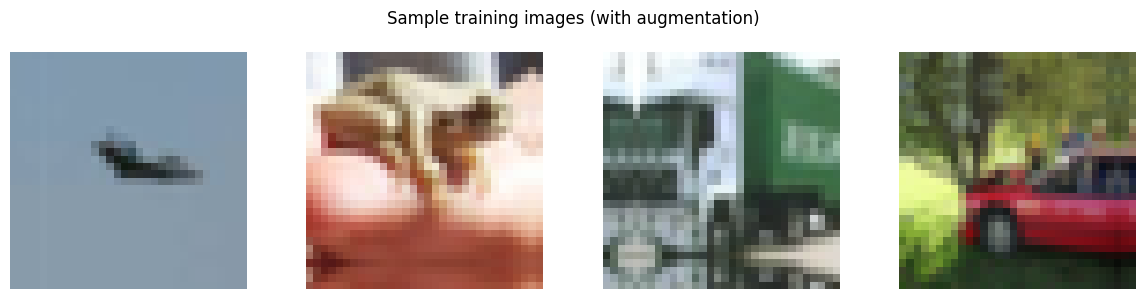

In [ ]:
# Test dataloader by viewing a few images:
num_images = 4
img_batch, label_batch = next(iter(train_loader))
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img, label in zip(axes, img_batch[:4], label_batch[:4]):
    img_np = np.clip(img.numpy(), 0, 1)
    ax.imshow(img_np)
    ax.axis('off')
plt.suptitle('Sample training images (with augmentation)')
plt.tight_layout()
plt.show()

b) Implement a ResNet20-style convolutional neural network classifier model for the CIFAR-10 dataset. Your implementation should be entirely in Keras, using the Sequential API and layer subclassing as necessary. The full spec for the model is as follows:

* Input Tensor of shape `(32, 32, 3)`
* Conv layer with $c=16$ filters, kernel size $k=3$, stride $s=1$, ReLU activation
* **Stage 1**: 3 residual blocks with $c=16$ filters and stride $s=1$
    * Each residual block with $c$ filters and stride $s$ is constructed as follows:
        * Conv layer with $c$ filters, $k=3$, stride $s$, ReLU activation
        * Conv layer with $c$ filters, $k=3$, stride 1, no activation
        * Skip connection that adds the layer input to the output of the previous conv layer
        * ReLU activation applied to the output of the skip connection
* **Stage 2**: 3 residual blocks with $c=32$ filters
    * Block 1: use $s=2$
        * Note that whenever the number of filters in the layer input is not equal to $c$ (as will be the case for this block), then it will not be possible to apply the skip connection. In this case, add the following convolutional layer as part of the skip connection:
            * Conv layer with $c$ filters, $k=1$, stride $s$, "VALID" padding
    * Blocks 2 & 3: use $s=1$
* **Stage 3**: 3 residual blocks with $c=64$ filters
    * Block 1: use $s=2$
    * Blocks 2 & 3: use $s=1$
* Spatial global average pooling (reduces out spatial dimensions)
* Dense layer with 10 output neurons, no activation, "He normal" initialisation

All convolutional layers should use "SAME" padding (unless otherwise indicated), L2 (kernel) weight regularisation, and the "He normal" initializer.

Print the model summary.

**(3 marks)**

In [12]:
class AlwaysDropout(keras.layers.Layer):
      def __init__(self, rate, **kwargs):
          super().__init__(**kwargs)
          self.dropout = keras.layers.Dropout(rate)

      def call(self, inputs):
          return self.dropout(inputs, training=True)

# Couldn't figure out how to use the sequential API with
# the skip connection so using functional API
def conv_layer(filters, stride, name, l2_penalty,kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'):
    layer = keras.layers.Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        strides=stride,
        activation=activation,
        padding=padding,
        kernel_regularizer=keras.regularizers.l2(l2_penalty),
        kernel_initializer=kernel_initializer,
        name=name
    )
    return layer

def residual_block(input, filters, stride, pref: str, l2_penalty, conv_skip=False, include_dropout=False, dropout_rate=0.2):
    """
    Build a residual block.
        input: input layer to use
        filters: number of filters to use in Conv layers
        stride: stride to use in Conv layers
        pref: prefix to use in layer names
        l2_penalty: l2 penalty to use in Conv layers
        conv_skip: whether or not to use a skip connection
        include_dropout: whether or not to include dropout layers
    """
    # First Convolution layer
    c1 = conv_layer(filters=filters,stride=stride, name=f'{pref}_Conv1', l2_penalty=l2_penalty )(input)
    if include_dropout:
        # Apply always-on dropout layer if flag set
        c1 = AlwaysDropout(rate=dropout_rate)(c1)
    # Second convolution layer in residual block
    c2 = conv_layer(filters=filters,stride=1, name=f'{pref}_Conv2', l2_penalty=l2_penalty, activation=None )(c1)
    if conv_skip:
        # If flag set, use convlution layer in skip connection
        skip = conv_layer(
            filters=filters,
            stride=stride,
            name=f'{pref}_ConvSkip',
            l2_penalty=l2_penalty,
            kernel_size=1,
            padding='valid',
            activation=None
        )(input)
        skipped = keras.layers.Add()([c2, skip])
    else:
        # regular skip connection connected directly to input
        skipped = keras.layers.Add()([c2, input])

    output = keras.layers.Activation('relu')(skipped)
    return output

def build_model(
        l2_penalty,
        model_name: str,
        include_dropout=False,
        dropout_rate=0.2
    ):
    """
    Builds a ResNet type model for the purpose of this assignment.
      l2_penalty: l2_penalty to use in Conv layers
      model_name: Model name
      include_dropout: Whether or not to include dropout layers
          in each residual block.
    """
    input_layer = keras.layers.Input(shape=(32,32,3),name='input')
    # Starting convolution layer
    stage1 = conv_layer(
        filters=16,
        stride=1,
        name='Input_Conv',
        l2_penalty=l2_penalty,
    )(input_layer)
    for i in range(3):
        # First three residual blocks (16 filters)
        stage1 = residual_block(
            stage1, filters=16, stride=1, pref=f'Stage1Block{i+1}',
            l2_penalty=l2_penalty, include_dropout=include_dropout,
            dropout_rate=dropout_rate
        )
    # Residual block with 32 filters (have to skip)
    stage2 = residual_block(
        stage1, filters=32, stride=2, pref='Stage2Block1',
        l2_penalty=l2_penalty, conv_skip=True, include_dropout=include_dropout
    )
    # Two more stage 2 blocks
    for i in range(2, 4):
        stage2 = residual_block(
            stage2, filters=32, stride=1, pref=f'Stage2Block{i}',
            l2_penalty=l2_penalty, include_dropout=include_dropout
        )
    # First stage 3 block with 64 filters (have to skip)
    stage3 = residual_block(
        stage2, filters=64, stride=2, pref='Stage3Block1',
        l2_penalty=l2_penalty, conv_skip=True, include_dropout=include_dropout
        )
    # Two more stage 3 blocks
    for i in range(2, 4):
        stage3 = residual_block(
            stage3, filters=64, stride=1, pref=f'Stage3Block{i}',
            l2_penalty=l2_penalty, include_dropout=include_dropout
            )

    pooled = keras.layers.GlobalAveragePooling2D()(stage3)
    output = keras.layers.Dense(
        units=10, activation=None, kernel_initializer='he_normal'
    )(pooled)
    return keras.Model(inputs=input_layer, outputs=output, name=model_name)


In [ ]:
summary_model1 = build_model(l2_penalty=0.01, model_name='ResNet20')


In [ ]:
summary_model1.summary()

Model: "ResNet20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Conv (Conv2D) │ (None, 32, 32,    │        448 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block1_Conv1  │ (None, 32, 32,    │      2,320 │ Input_Conv[0][0]  │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block1_Conv2  │ (None, 32, 32,    │      2,320 │ Stage1Block1_Con… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ Stage1Block1_Con… │
│                     │ 16)               │            │ Input_Conv[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block2_Conv1  │ (None, 32, 32,    │      2,320 │ activation[0][0]  │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block2_Conv2  │ (None, 32, 32,    │      2,320 │ Stage1Block2_Con… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ Stage1Block2_Con… │
│                     │ 16)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block3_Conv1  │ (None, 32, 32,    │      2,320 │ activation_1[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block3_Conv2  │ (None, 32, 32,    │      2,320 │ Stage1Block3_Con… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ Stage1Block3_Con… │
│                     │ 16)               │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add_2[0][0]       │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage2Block1_Conv1  │ (None, 16, 16,    │      4,640 │ activation_2[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage2Block1_Conv2  │ (None, 16, 16,    │      9,248 │ Stage2Block1_Con… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage2Block1_ConvS… │ (None, 16, 16,    │        544 │ activation_2[0][… │
│ (Conv2D)            │ 32)               │            │                 

 Total params: 271,690 (1.04 MB)

 Trainable params: 271,690 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

c) Train your model on the CIFAR-10 dataset using the high-level Keras API for maximum 200 epochs, using SGD with momentum. Your training run should track the categorical accuracy metric, and save the best model according to the loss on the validation set. You should select any hyperparameters to try to maximise the validation accuracy of the model.

Compute and print out the final evaluation of your model on the test set.

_Make sure to save your trained model, as it will be used in later questions in this assessment._

**(2 marks)**

In [ ]:
# Note we are not using 1-hot encoding so we have to use
# sparse loss + metrics

def fit_model(
        model,
        train_loader,
        val_loader,
        learning_rate,
        momentum,
        epochs,
        save_path,
        use_early_stopping=False,
        verbose: int = 0,
        ):
    """
    Train model on CIFAR-10 dataset.
        model: model to fit
        train_loader: training data loader
        val_loader: validation data loader
        learning_rate: learning rate to use in training
        momentum: momentum to use in training
        epochs: number of epochs to train for
        save_path: path to save best model to
    """

    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=momentum,
            clipnorm=1.0),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy()
        ],
    )
    early_stopping = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      patience=10,
      restore_best_weights=True  # automatically restores best weights
    )
    checkpoint = keras.callbacks.ModelCheckpoint(
      save_path,
      monitor='val_loss',
      save_best_only=True
    )
    callbacks = [checkpoint]
    if use_early_stopping:
        callbacks.append(early_stopping)
    history = model.fit(
      train_loader,
      validation_data=val_loader,
      epochs=epochs,
      callbacks=callbacks,
      verbose=verbose
  )

    return history

#### sample_theta and set_flat_weights for SWAG

In [23]:
def evaluate_model(model: keras.Model, swag=None, d: int=None, K: int=None, use_val: bool=False):
    loss_metric     = keras.metrics.SparseCategoricalCrossentropy(from_logits=True)
    accuracy_metric = keras.metrics.SparseCategoricalAccuracy()

    loader = val_loader if use_val else test_loader
    for images, labels in loader:
        images = np.array(images)
        labels = np.array(labels)

        if swag is not None:
            theta_tilde = sample_theta(swag, d, K)
            set_flat_weights(model, theta_tilde)

        preds = model(images, training=False)
        loss_metric.update_state(labels, preds)
        accuracy_metric.update_state(labels, preds)
    test_set = 'val' if use_val else 'test'
    logging.info(f"{model.name} {test_set} loss: {loss_metric.result():.4f}")
    logging.info(f"{model.name} {test_set} accuracy: {accuracy_metric.result():.4f}")

In [ ]:

def run_experiment(experiment: dict, epochs:int=200, trloader=train_loader, vloader=val_loader,verbose=0):
    model = build_model(l2_penalty=experiment['l2'], model_name='ResNet20')
    history = fit_model(model, trloader, vloader,
                        learning_rate=experiment['lr'], momentum=experiment['momentum'], epochs=epochs,
                        save_path=f"{SAVE_ROOT}/{experiment['name']}_model_lr{experiment['lr']}" + \
                            f"_l2{experiment['l2']}_mom{experiment['momentum']}.keras",
                        use_early_stopping=True, verbose=verbose
                        )
    val_acc = max(history.history['val_sparse_categorical_accuracy'])
    logging.info(f"lr={experiment['lr']}, l2={experiment['l2']} -> best val acc: {val_acc:.4f}, "+
          f" epochs trained: {len(history.history['loss'])}")
    del model
    gc.collect()



### Learning Rate, L2 Penalty, Momentum Experiments

In [ ]:

experiments = [
      {'name':'hyper', 'lr': 0.1,  'l2': 1e-4, 'momentum':0.9},
      {'name':'hyper','lr': 0.1,  'l2': 1e-3, 'momentum':0.9},
      {'name':'hyper','lr': 0.05, 'l2': 1e-4, 'momentum':0.9},
      {'name':'hyper','lr': 0.01, 'l2': 1e-4, 'momentum':0.9},
      {'name':'hyper','lr': 0.01,  'l2': 1e-3, 'momentum':0.9},
      {'name':'hyper','lr': 0.005, 'l2': 1e-4, 'momentum':0.9},
      {'name':'hyper','lr': 0.01, 'l2': 1e-5, 'momentum':0.9},
      {'name':'mom','lr': 0.01,  'l2': 1e-4, 'momentum':0.7},
      {'name':'mom','lr': 0.01,  'l2': 1e-4, 'momentum':0.8},
      {'name':'mom','lr': 0.01,  'l2': 1e-4, 'momentum':0.9},
      {'name':'mom','lr': 0.01, 'l2': 1e-4, 'momentum':1.0},
  ]

for exp in experiments:
    run_experiment(exp)

2026-03-24 22:17:10,400 lr=0.1, l2=0.0001 -> best val acc: 0.1055,  epochs trained: 73
2026-03-24 22:21:37,509 lr=0.1, l2=0.001 -> best val acc: 0.1055,  epochs trained: 27
2026-03-24 22:28:43,739 lr=0.05, l2=0.0001 -> best val acc: 0.8178,  epochs trained: 43
2026-03-24 22:41:15,228 lr=0.01, l2=0.0001 -> best val acc: 0.8608,  epochs trained: 76
2026-03-24 22:52:57,153 lr=0.01, l2=0.001 -> best val acc: 0.8518,  epochs trained: 71
2026-03-24 23:08:33,876 lr=0.005, l2=0.0001 -> best val acc: 0.8484,  epochs trained: 95
2026-03-24 23:17:57,939 lr=0.01, l2=1e-05 -> best val acc: 0.8309,  epochs trained: 57
2026-03-24 23:33:15,501 lr=0.01, l2=0.0001 -> best val acc: 0.8308,  epochs trained: 93
2026-03-24 23:47:33,614 lr=0.01, l2=0.0001 -> best val acc: 0.8504,  epochs trained: 87
2026-03-24 23:58:44,794 lr=0.01, l2=0.0001 -> best val acc: 0.8521,  epochs trained: 68
2026-03-25 00:00:33,485 lr=0.01, l2=0.0001 -> best val acc: 0.1621,  epochs trained: 11


### Batch Size Experiments

In [ ]:
for bsize in [64, 128, 256]:
    exp_train_loader = DataLoader(CIFAR10Dataset(x_train, y_train, transform=True), batch_size=bsize, shuffle=True)
    exp_val_loader = DataLoader(CIFAR10Dataset(x_val, y_val, transform=False), batch_size=bsize, shuffle=False)
    logging.info(f'Batch Size {bsize}: ')
    run_experiment( {'name':'bsize','lr': 0.01, 'l2': 1e-4, 'momentum':0.9}, epochs=200, trloader=exp_train_loader, vloader=exp_val_loader)

2026-03-25 00:02:08,922 Batch Size 64: 
2026-03-25 00:22:18,332 lr=0.01, l2=0.0001 -> best val acc: 0.8602,  epochs trained: 66
2026-03-25 00:22:18,588 Batch Size 128: 
2026-03-25 00:36:37,872 lr=0.01, l2=0.0001 -> best val acc: 0.8638,  epochs trained: 87
2026-03-25 00:36:38,128 Batch Size 256: 
2026-03-25 00:45:00,250 lr=0.01, l2=0.0001 -> best val acc: 0.8513,  epochs trained: 87


In [19]:
# Final Loaders (after tuning Batch Size)
BATCH_SIZE = 128
train_loader = DataLoader(CIFAR10Dataset(x_train, y_train, transform=True), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CIFAR10Dataset(x_val, y_val, transform=False), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CIFAR10Dataset(x_test, y_test, transform=False), batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Fit best model after experiments
model1 = build_model(l2_penalty=1e-4, model_name='DetResNet20')
history = fit_model(model1, train_loader, val_loader,
                        learning_rate=0.01, momentum=0.9, epochs=200,
                        save_path=f"{SAVE_ROOT}/model_lr_best" + \
                            "_l2_best.keras",
                        use_early_stopping=False
                        )
val_acc = max(history.history['val_sparse_categorical_accuracy'])
logging.info(f"lr={0.01}, l2={1e-4} → best val acc: {val_acc:.4f}, "+
        f" epochs trained: {len(history.history['loss'])}")

2026-03-25 01:18:14,928 lr=0.01, l2=0.0001 → best val acc: 0.8839,  epochs trained: 200


In [ ]:
model1 = keras.models.load_model(
    f"{SAVE_ROOT}/model_lr_best_l2_best.keras",
    custom_objects={'AlwaysDropout': AlwaysDropout}
)
evaluate_model(model1)

2026-03-25 01:18:26,944 DetResNet20 test loss: 0.4365
2026-03-25 01:18:26,945 DetResNet20 test accuracy: 0.8776


d) Define a second model on the CIFAR-10 dataset. This model should be the same as the model defined in part b), except an additional dropout layer should be included in between the two convolutional layers in every residual block. The model should be defined such that the stochastic dropout mechanism is active at test time as well as at training time. Therefore the model will be a Bayesian neural network implementation, that uses the MC Dropout technique to approximate the posterior distribution.

Aside from the additional dropout layers, the model architecture should be identical to the model in part b).

Print the model summary, and train the model with the same training settings you used in part c).

Compute and print out the final evaluation of your model on the test set (using a single MC sample for each data example).

_Make sure to save your trained model, as it will be used in later questions in this assessment._

**(3 marks)**

### Dropout Rate Experiments

In [ ]:
for drate in [0.05, 0.1,0.2]:
    mc_model = build_model(l2_penalty=1e-4, model_name='MCDropoutExp',
                           include_dropout=True, dropout_rate=drate
                           )
    mc_lr = 0.01
    historymc = fit_model(
        mc_model, train_loader=train_loader, val_loader=val_loader,
        learning_rate=mc_lr, momentum=0.9,epochs=200,
        save_path=f"{SAVE_ROOT}/model_mcdropout_{drate}.keras",
        use_early_stopping=True, verbose=0
    )
    val_mcexp = max(historymc.history['val_sparse_categorical_accuracy'])
    logging.info(f"dropout_rate: {drate} → best val acc: {val_mcexp:.4f}, "+
            f" epochs trained: {len(historymc.history['loss'])}")

2026-03-24 13:34:14,129 dropout_rate: 0.05 → best val acc: 0.8501,  epochs trained: 95
2026-03-24 12:55:50,699 dropout_rate: 0.1 → best val acc: 0.8549,  epochs trained: 100
2026-03-24 13:14:29,081 dropout_rate: 0.2 → best val acc: 0.8484,  epochs trained: 103


## MC Dropout Model Definition

In [ ]:
model2 = build_model(l2_penalty=1e-4, model_name='MCDropout', include_dropout=True, dropout_rate=0.1)

In [ ]:
model2.summary()

Model: "MCDropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Conv (Conv2D) │ (None, 32, 32,    │        448 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block1_Conv1  │ (None, 32, 32,    │      2,320 │ Input_Conv[0][0]  │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ always_dropout_27   │ (None, 32, 32,    │          0 │ Stage1Block1_Con… │
│ (AlwaysDropout)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block1_Conv2  │ (None, 32, 32,    │      2,320 │ always_dropout_2… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_180 (Add)       │ (None, 32, 32,    │          0 │ Stage1Block1_Con… │
│                     │ 16)               │            │ Input_Conv[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_180      │ (None, 32, 32,    │          0 │ add_180[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block2_Conv1  │ (None, 32, 32,    │      2,320 │ activation_180[0… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ always_dropout_28   │ (None, 32, 32,    │          0 │ Stage1Block2_Con… │
│ (AlwaysDropout)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block2_Conv2  │ (None, 32, 32,    │      2,320 │ always_dropout_2… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_181 (Add)       │ (None, 32, 32,    │          0 │ Stage1Block2_Con… │
│                     │ 16)               │            │ activation_180[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_181      │ (None, 32, 32,    │          0 │ add_181[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block3_Conv1  │ (None, 32, 32,    │      2,320 │ activation_181[0… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ always_dropout_29   │ (None, 32, 32,    │          0 │ Stage1Block3_Con… │
│ (AlwaysDropout)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stage1Block3_Conv2  │ (None, 32, 32,    │      2,320 │ always_dropout_2… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_182 (Add)       │ (None, 32, 32,    │          0 │ Stage1Block3_Con… │
│                     │ 16)               │            │ activation_181[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_182      │ (None, 32, 32,    │          0 │ add_182[0][0]     │
│ (Activation)        │ 16)               │            │                 

 Total params: 271,690 (1.04 MB)

 Trainable params: 271,690 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lr2 = 0.01
history2 = fit_model(
    model2, train_loader=train_loader, val_loader=val_loader,
    learning_rate=lr2, momentum=0.9,epochs=200,
    save_path=f"{SAVE_ROOT}/model_mcdropout.keras",
    )
val_acc2 = max(history2.history['val_sparse_categorical_accuracy'])
logging.info(f"lr={lr2}, l2={1e-4} → best val acc: {val_acc2:.4f}, "+
        f" epochs trained: {len(history2.history['loss'])}")

2026-03-25 02:43:14,640 lr=0.01, l2=0.0001 → best val acc: 0.8679,  epochs trained: 200


In [ ]:
model2 = keras.models.load_model(
    f"{SAVE_ROOT}/model_mcdropout.keras",
    custom_objects={'AlwaysDropout': AlwaysDropout}
)
evaluate_model(model2)

2026-03-25 02:43:15,665 MCDropout test loss: 0.4470
2026-03-25 02:43:15,666 MCDropout test accuracy: 0.8587


### Question 2 (Total 15 marks)

SWA-Gaussian (SWAG) is another Bayesian neural network approach that builds on Stochastic Weight Averaging (SWA) by using model weights collected during a final phase of training to fit a Gaussian distribution as the approximation to the posterior distribution.

* Maddox, W. J., Izmailov, P., Garipov, T., Vetroc, D. P. and Wilson, A. G. (2019), "A Simple Baseline for Bayesian Uncertainty in Deep Learning", _Advances in Neural Information Processing Systems_, **32**, 2019.
* Izmailov, P., Podoprikhin, D., Garipov, T., Vetrov, D., and Wilson, A. G. (2018), "Averaging weights leads to wider optima and better generalization", in _Uncertainty in Artificial Intelligence (UAI)_, 876-885.

The process consists of two main phases:

1. A first phase of standard training to convergence, or use a pre-trained model.
2. A second stage (the SWA phase) where the training is continued, using a high constant or cyclical learning rate, typically using SGD with momentum. In this phase, the training explores the region surrounding the local optimum in weight space. Let $\theta_i$ denote the model weights after epoch $i$ in the SWA phase. The algorithm maintains a running average of the weights after $T$ epochs of this phase $\overline{\theta}_T := \frac{1}{T}\sum_{i=1}^T \theta_i$, and a running average of the squared weights $(\overline{\theta^2})_T := \frac{1}{T}\sum_{i=1}^T \theta^2_i$. It also stores a deviation matrix $D$, with columns $D_i = (\theta_i - \overline{\theta}_i)$, so that after $T$ epochs in this phase, $D$ will have $p$ rows and $T$ columns, where $p$ is the total number of trainable parameters in the model.

Once the two stages above are complete, the posterior approximation is given by a Gaussian distribution with mean $\overline{\theta}_T$ (also referred to as the SWA solution $\theta_{SWA}$), and whose covariance matrix is given by $\frac{1}{2}(\Sigma_{\text{diag}} + \Sigma_{\text{low-rank}})$. $\Sigma_{\text{diag}}$ is a diagonal matrix given by $\Sigma_{\text{diag}} := \text{diag}((\overline{\theta^2})_T - (\overline{\theta}_T)^2)$. $\Sigma_{\text{low-rank}}$ is a low-rank estimate of the covariance matrix which uses the last $K$ columns of $D$, corresponding to the last $K$ epochs of training. $\Sigma_{\text{low-rank}}$ is then given by $\Sigma_{\text{low-rank}} := \frac{1}{K-1}\hat{D}\hat{D}^T$, where $\hat{D}$ is the matrix with columns equal to $D_i$ for $i=T − K + 1,\ldots, T$.  $K$ is the rank of the resulting approximation and is a hyperparameter of the method.

a) You should implement a custom Keras callback to handle the SWAG collection process (phase 2 above). Your custom callback will be used within a regular `model.fit` call, and should be used to collect the running averages of the model weights, as well as the running averages of the squared weights, and the deviation matrix. The running averages and deviation matrix should be updated at the end of every epoch. You can assume that phase 1 above has already been completed, so that the model that is used with the custom callback is starting from a pre-trained state.

You may find it helpful to break your custom callback implementation down using helper functions or classes.

**(6 marks)**

In [15]:
# Below was written with the help of documentation from
# https://keras.io/guides/writing_your_own_callbacks/
class SWAGCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.theta_avg = 0
        self.theta_sq_avg = 0
        self.D_cols = []
        self.t = 0

    def get_weights(self):
        weights = np.concatenate([
            v.numpy().flatten() for v in self.model.trainable_variables
            ])
        return weights

    def de_average(self):
        self.theta_avg *= self.t
        self.theta_sq_avg *= self.t

    def on_epoch_end(self, epoch, logs=None):
        theta = self.get_weights()
        self.de_average()
        self.t += 1
        self.theta_avg = (self.theta_avg + theta) / self.t
        self.theta_sq_avg = (self.theta_sq_avg + (theta ** 2)) / self.t
        self.D_cols.append((theta - self.theta_avg))

    def get_D(self):
        return np.column_stack(self.D_cols)  # shape (p, T)


In [16]:
def sample_theta(swag: SWAGCallback, d: int, K: int):
    # Ssamle
    # NOTE: Defined here so that it is next to the question defintion
    # but called in evaluate_model if swag is passed
    D_hat = swag.get_D()[:, -K:]
    z1 = np.random.normal(size=d)
    z2 = np.random.normal(size=K)
    sigma_diag = swag.theta_sq_avg - swag.theta_avg ** 2
    theta_tilde = swag.theta_avg + (1/np.sqrt(2)) * np.sqrt(sigma_diag) * z1 \
                  + (1/np.sqrt(2 * (K - 1))) * D_hat @ z2
    return theta_tilde

In [17]:
def set_flat_weights(model, flat_weights):
    # NOTE: Defined here so that it is next to the question defintion
    # but called in evaluate_model if swag is passed
    idx = 0
    for v in model.trainable_variables:
        size = np.prod(v.shape)
        v.assign(flat_weights[idx:idx+size].reshape(v.shape))
        idx += size

b) Use your custom callback with the pre-trained (deterministic) model from question 1b) and 1c).

You should load the saved best model, and run additional epochs of training, using the `.fit()` method and your custom callback to collect the running averages and deviation matrix required for the SWAG posterior approximation. It is recommended to save the model weights that are used in this approximation. You should collect at least 20 snapshots (i.e. $K\ge 20$) of the model weights.

_If you were not able to implement the architecture specified in 1b) you can still complete this question (and following questions) using trained classifier model with an alternative architecture._

**(4 marks)**

In [13]:
def get_best_model(num: int) -> keras.Model:
    # Implemented so that I could decide best model after writing
    # code for 2b). Just returns the current best model
    if num == 1:
        path = f"{SAVE_ROOT}/model_lr_best_l2_best.keras"
    else:
        path = f"{SAVE_ROOT}/model_mcdropout.keras"
    best_model = keras.models.load_model(
        path,
        custom_objects={'AlwaysDropout': AlwaysDropout}
        )
    return best_model

## SWAG Experiments

### K value and SWAG epochs



In [18]:
for n_epochs in [40, 60, 80, 100]:
    swag_model = get_best_model(1)  # reload fresh each time
    swag_model.name = 'SWAG'
    swag = SWAGCallback()
    swag_model.fit(train_loader, validation_data=val_loader, epochs=n_epochs, callbacks=[swag], verbose=0)
    for k in range(20, min((n_epochs+20), 120), 20):
        logging.info(f"SWAG epochs={n_epochs}, K={k}")
        evaluate_model(swag_model, swag, len(swag.theta_avg), K=k, use_val=True)

2026-03-25 02:49:53,542 SWAG epochs=40, K=202026-03-25 02:50:01,218 SWAG val loss: 0.44242026-03-25 02:50:01,219 SWAG val accuracy: 0.88182026-03-25 02:50:01,219 SWAG epochs=40, K=402026-03-25 02:50:09,690 SWAG val loss: 0.43222026-03-25 02:50:09,690 SWAG val accuracy: 0.88712026-03-25 03:00:05,256 SWAG epochs=60, K=202026-03-25 03:00:14,087 SWAG val loss: 0.45832026-03-25 03:00:14,088 SWAG val accuracy: 0.87802026-03-25 03:00:14,088 SWAG epochs=60, K=402026-03-25 03:00:23,852 SWAG val loss: 0.45002026-03-25 03:00:23,852 SWAG val accuracy: 0.87942026-03-25 03:00:23,853 SWAG epochs=60, K=602026-03-25 03:00:32,375 SWAG val loss: 0.46462026-03-25 03:00:32,376 SWAG val accuracy: 0.87902026-03-25 03:13:49,738 SWAG epochs=80, K=202026-03-25 03:13:58,424 SWAG val loss: 0.45752026-03-25 03:13:58,425 SWAG val accuracy: 0.88102026-03-25 03:13:58,427 SWAG epochs=80, K=402026-03-25 03:14:05,812 SWAG val loss: 0.46202026-03-25 03:14:05,813 SWAG val accuracy: 0.87662026-03-25 03:14:05,813 SWAG epoch

## Best SWAG Model

In [21]:
model1 = get_best_model(1)
model2 = get_best_model(2)
swag_model = get_best_model(1)
swag_model.name = 'SWAG'
swag = SWAGCallback()
K = 40
swag_history = swag_model.fit(train_loader, validation_data=val_loader,
               epochs=40, callbacks=[swag], verbose=0)
swag_model.save(f"{SAVE_ROOT}/swag_model.keras")
swag_val_acc = max(swag_history.history['val_sparse_categorical_accuracy'])
logging.info(f"best val acc: {swag_val_acc:.4f}, "+
        f" epochs trained: {len(swag_history.history['loss'])}")

2026-03-25 11:05:15,254 best val acc: 0.8798,  epochs trained: 40


c) As described above, in SWAG the posterior approximation is given by the Gaussian distribution $N(\theta_{SWA}, \frac{1}{2}(\Sigma_{\text{diag}} + \Sigma_{\text{low-rank}}))$. Parameters $\tilde{\theta}$ can be sampled from this distribution using the following identity

$$\tilde{\theta} = \theta_{SWA} + \frac{1}{\sqrt{2}} \Sigma_{\text{diag}}^{\frac{1}{2}} z_1 + \frac{1}{\sqrt{2(K-1)}} \hat{D} z_2,\qquad \text{with }z_1\sim N(\mathbf{0},\mathbf{I}_d),~z_2\sim N(\mathbf{0},\mathbf{I}_K),$$

where $d$ is the number of parameters in the network.

Compute the test loss and accuracy for the SWAG model, using the above identity to sample a single set of parameters per batch of data examples (using an ensemble size of one).

**(5 marks)**

In [24]:
evaluate_model(swag_model, swag, len(swag.theta_avg), K)

2026-03-25 11:08:47,457 SWAG test loss: 0.4527
2026-03-25 11:08:47,460 SWAG test accuracy: 0.8799


### Question 3 (Total 10 marks)

Recall that with Bayesian neural networks, once we have our posterior distribution approximation $q_\phi(\theta)$, we can compute the predictive distribution by drawing multiple $S$ samples from the approximate posterior:

$$p(y^* \mid x^*, \mathcal{D}) \approx \frac{1}{S} \sum_{s=1}^S p(y^* \mid x^*, \theta_s),\qquad \theta_s\sim q_\phi(\theta).$$

a) Use the predictive distribution with $S\ge30$ to compute the test loss and accuracy for the MC Dropout model of question 1d) as well as the SWAG model of question 2.

**(3 marks)**

In [26]:
def mc_dropout_predictive_distribution(model, images, S=30):
    """
    Computes the predictive distribution using MC Dropout.
    """
    probs = []
    for _ in range(S):
        logits = model(images, training=True)
        probs.append(ops.convert_to_numpy(keras.ops.softmax(logits, axis=-1)))
    return np.mean(probs, axis=0)  # (batch_size, 10)

def swag_predictive(model, images, d, K, S=30):
    probs = []
    for _ in range(S):
        theta_tilde = sample_theta(swag, d, K)
        set_flat_weights(model, theta_tilde)
        preds = model(images, training=False)
        probs.append(ops.convert_to_numpy(keras.ops.softmax(preds, axis=-1)))
    return np.mean(probs, axis=0)  # (batch_size, 10)

In [38]:
def evaluate_predictive(model, loader, predict_fn):
      loss_metric     = keras.metrics.SparseCategoricalCrossentropy()
      accuracy_metric = keras.metrics.SparseCategoricalAccuracy()

      for images, labels in loader:
          images = np.array(images)
          labels = np.array(labels)
          probs = predict_fn(model, images)   # (batch_size, 10)
          loss_metric.update_state(labels, probs)
          accuracy_metric.update_state(labels, probs)

      return loss_metric.result(), accuracy_metric.result()

In [28]:
mc_loss, mc_acc = evaluate_predictive(
      model2, test_loader,
      lambda model, images: mc_dropout_predictive_distribution(model, images, S=30)
  )

swag_loss, swag_acc = evaluate_predictive(
      swag_model, test_loader,
      lambda model, images: swag_predictive(model, images, d=len(swag.theta_avg), K=K, S=30)
  )


In [29]:
print(f"MC Dropout predictive test loss: {mc_loss:.4f}, MC Dropout predictive accuracy: {mc_acc:.4f}")
print(f"SWAG predictive test loss: {swag_loss:.4f}, SWAG predictive accuracy: {swag_acc:.4f}")

MC Dropout predictive test loss: 0.3513, MC Dropout predictive accuracy: 0.8789
SWAG predictive test loss: 0.3148, SWAG predictive accuracy: 0.9000


#### Expected calibration error

In addition to classification accuracy, probabilistic classifiers should ideally also produce well-calibrated predictions.

A classifier is said to be well-calibrated if the confidence it assigns to its predictions matches how often those predictinos are actually correct. We will define confidence to be the maximum probability output by the model for a given data example. For example, for all predictions made by the model with confidence close to 0.8, we would expect these predictions to be correct approximately 80% of the time. A model that is accurate but over-confident or under-confident is poorly calibrated.

A standard metric for calibration is the **Expected Calibration Error (ECE)**. This is computed as follows:

* Computing all predictions and confidence scores from a model across the test dataset
* Partition the predictions into confidence bins: divide the interval $[0, 1]$ into equally sized bins $B_m$, $m=1,\ldots,M$
* For each test example, assign it to the corresponding confidence bin according to the model's confidence score
* Compute the average accuracy and confidence scores within each confidence bin $B_m$:
    * Let $\text{acc}(B_m)$ be the fraction of correctly classified examples in the bin
    * Let $\text{conf}(B_m)$ be the average confidence score of the predictions in the bin
* The ECE is then given by:

$$ECE = \sum_{m=1}^M \frac{|B_m|}{N} |\text{acc}(B_m) - \text{conf}(B_m)|,$$

where $|B_m|$ is the number of examples in the bin $B_m$, and $N$ is the total number of test examples.

Smaller ECE values indicated better calibration. Perfect calibration would have an ECE score of zero.

b) Compute and print out the ECE scores for each of the three models developed in this coursework:

* The deterministic CNN model of question 1b) and c)
* The MC Dropout model of question 1d) (using the predictive distribution with $S\ge30$)
* The SWAG model of question 2 (using the predictive distribution with $S\ge30$)

Use 20 bins for the ECE calculations in each case.

**(5 marks)**

In [30]:

def compute_ece(confidences, corrects, M=20):
    bins = np.linspace(0, 1, M+ 1) # we will compare against m+1
    n = np.float32(len(confidences))
    total = 0
    binned_conf = []
    binned_acc = []
    for m in range(M):
        bin_mask = (confidences > bins[m]) & (confidences <= bins[m+1])
        bin_len = bin_mask.sum()
        if bin_len == 0:
            # nothing in this bin
            continue
        acc_bin = corrects[bin_mask].mean()
        conf_bin = confidences[bin_mask].mean()
        total += (bin_len / n) * np.abs(acc_bin - conf_bin)
        binned_conf.append(conf_bin)
        binned_acc.append(acc_bin)
    return total, binned_conf, binned_acc

def get_probs_preds(model, test_loader, predict_fn):
    all_confidences = []
    all_correct_guesses = []
    for images, labels in test_loader:
        images = np.array(images)
        labels = np.array(labels)
        probs = predict_fn(model, images) # (batch_size, 10)
        confidences = np.max(probs, axis=-1)       # keep largest prob over all 10 classes (batch_size,)
        predicted_classes = np.argmax(probs, axis=-1)  # get the class of the largest prob (batch_size,)
        corrects = (predicted_classes == labels)   # which predictions were correct (batch_size,)
        all_confidences.append(confidences) # confidence of prediction
        all_correct_guesses.append(corrects) # correctness of prediction
    # turn list into NP arrays
    return np.concatenate(all_confidences), np.concatenate(all_correct_guesses)

### Experimenting with S

In [39]:
for S in [10, 20, 30, 40, 50]:
    mc_loss, mc_acc = evaluate_predictive(
        model2, val_loader, # Given we're experimenting use val_loader
        lambda model, images: mc_dropout_predictive_distribution(model, images, S=S)
    )
    logging.info(f"S={S} → MC Dropout acc: {mc_acc:.4f}")

2026-03-25 11:18:53,516 S=10 → MC Dropout acc: 0.8881
2026-03-25 11:19:10,301 S=20 → MC Dropout acc: 0.8893
2026-03-25 11:19:34,931 S=30 → MC Dropout acc: 0.8890
2026-03-25 11:20:07,816 S=40 → MC Dropout acc: 0.8905
2026-03-25 11:20:48,663 S=50 → MC Dropout acc: 0.8903


### Deterministic CNN Model

In [31]:
confidences1, corrects1 = get_probs_preds(
      model1, test_loader,
      lambda model, images: keras.ops.convert_to_numpy(keras.ops.softmax(model(images, training=False), axis=-1))
  )
model1_ece, conf_m1_binned, acc_m1_binned = compute_ece(confidences1, corrects1, M=20)

In [32]:
print(f"Deterministic CNN ECE: {model1_ece:.4f}")

Deterministic CNN ECE: 0.0554


### MC Dropout Model

In [40]:
confidences2, corrects2 = get_probs_preds(
    model2, test_loader,
    lambda model, images: mc_dropout_predictive_distribution(model, images, S=40)
)
model2_ece, conf_m2_binned, acc_m2_binned = compute_ece(confidences2, corrects2, M=20)

In [42]:
print(f"MC Dropout ECE: {model2_ece:.4f}")

MC Dropout ECE: 0.0111


### SWAG Model

In [41]:
confidences_swag, corrects_swag = get_probs_preds(
      swag_model, test_loader,
      lambda model, images: swag_predictive(model, images, d=len(swag.theta_avg), K=K, S=40)
  )
models_ece, conf_ms_binned, acc_ms_binned = compute_ece(confidences_swag, corrects_swag, M=20)

In [43]:
print(f"SWAG Model ECE: {models_ece:.4f}")

SWAG Model ECE: 0.0167


#### Reliability diagram

A related and useful visual representation for a model's calibration is a **reliability diagram**. A reliability diagram shows, for different levels of predicted confidence, how often the model's predictions are actually correct. Following the notation from the previous question, the reliability diagram is a line plot that plots $\text{acc}(B_m)$ (predictive accuracy for bin $B_m$) against $\text{conf}(B_m)$ (average confidence for bin $B_m$).

c) Make reliability diagrams for each of the same three models as described in part b.

**(2 marks)**

In [44]:
def reliability_diagram(con_binned, acc_binned, model_name):
    plt.plot(con_binned, acc_binned)
    plt.ylabel('Predictive Accuracy for bin $B_m$')
    plt.xlabel('Average Confidence for bin $B_m$')
    plt.title(f'Reliability Diagram for {model_name} Model')

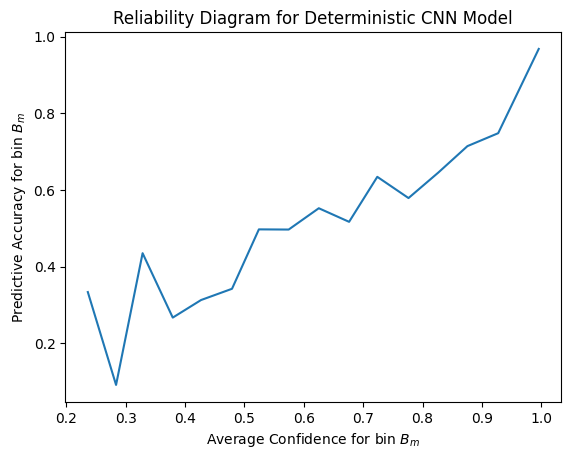

In [45]:
reliability_diagram(conf_m1_binned, acc_m1_binned, f'Deterministic CNN')

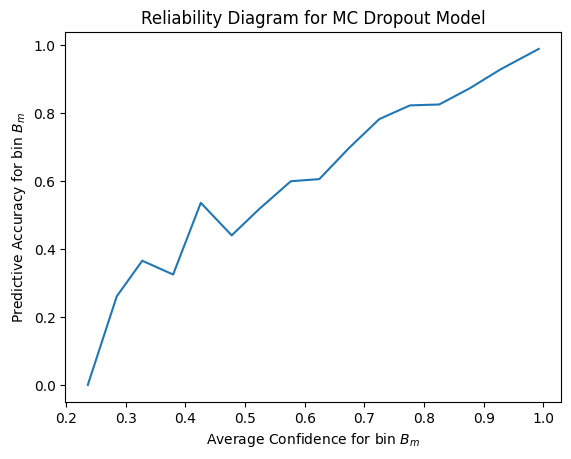

In [46]:
reliability_diagram(conf_m2_binned, acc_m2_binned, f'MC Dropout')

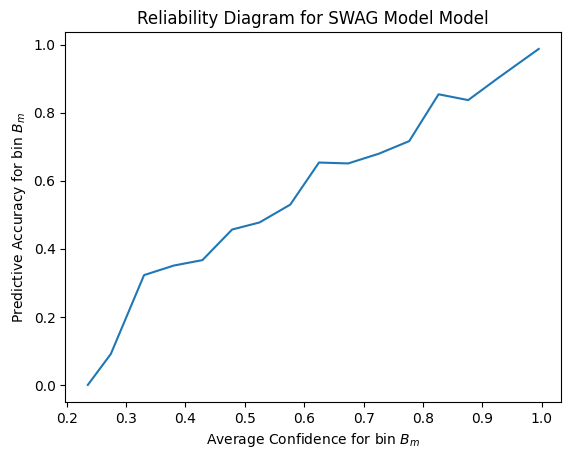

In [47]:
reliability_diagram(conf_ms_binned, acc_ms_binned, f'SWAG Model')

#### Question 4 (Total 10 marks)

Provide a separate PDF report with an account of the experiments you have run in this assessment. Your report should include details of the results from all experiments, the hyperparameter settings, and any other choices you have made throughout the development of the models. If you encountered difficulties to successfully train the model(s) you should report these, and if possible suggest what you think might be potential reasons for these difficulties.

Your report should also include your interpretation and analysis of the results, and what you think they might suggest about different models developed in this coursework.

Marks will be awarded for presentation and clarity. Your report should be no more than 2 pages, excluding any references and figures (which can be included in an appendix).

**(10 marks)**